In [20]:
import proximitygraphs as pg
from proximitygraphs.biologicalgraphs import FungalGraph
import numpy as np
import matplotlib.pyplot as plt

# Physalum Polycephalum

In [21]:
random_state = 0
points = pg.SetPoints.uniform_square(20, seed=random_state)

(<Figure size 800x800 with 1 Axes>, <Axes: title={'center': 'SetPoints'}>)

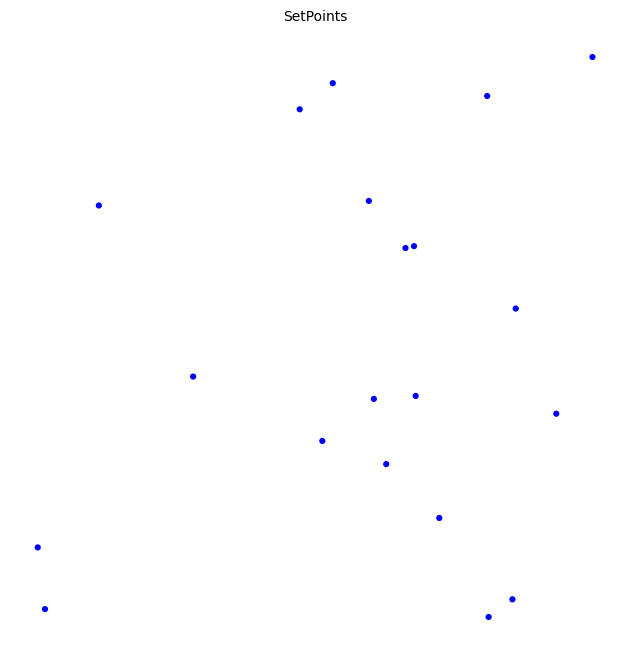

In [22]:
points.draw(figsize=(8, 8), v_color='blue', v_size=20)

(<Figure size 700x700 with 1 Axes>, <Axes: title={'center': 'Physarum Graph'}>)

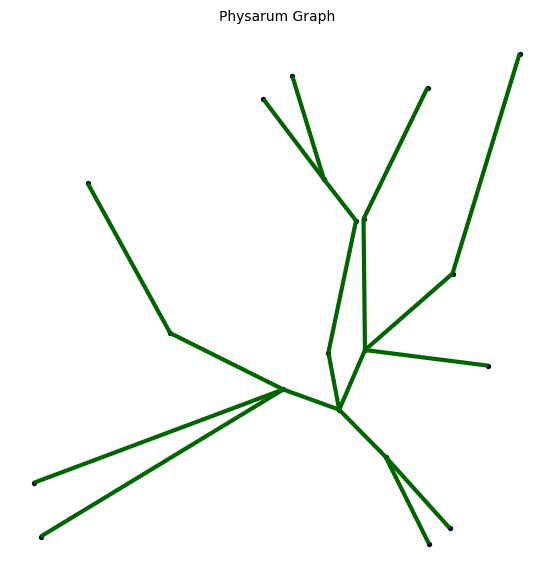

In [23]:
ph = pg.PhysarumGraph(points, sources=[0], steps=1000, dt=0.05, gamma=1.2, eps=1e-3, base_graph='delaunay')
ph.draw(
    figsize=(7, 7),
    e_size=[3],
    e_color="darkgreen",
    v_size=8
)

Nodos: 20
Aristas: 30
Componentes conexas: 1


(<Figure size 700x700 with 1 Axes>, <Axes: title={'center': 'Fungal Graph'}>)

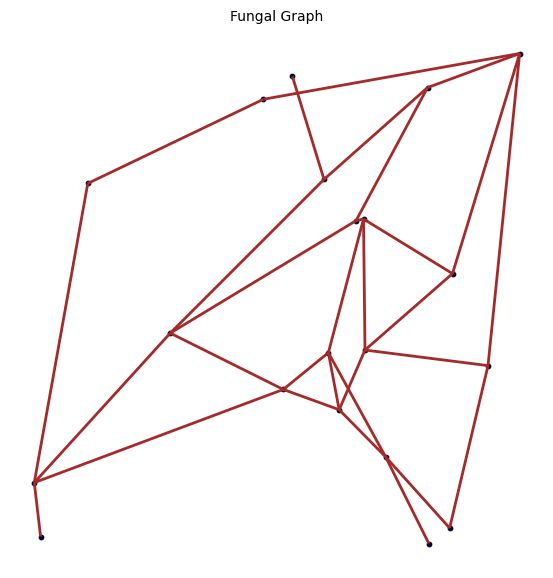

In [24]:
fg = FungalGraph(points, sources=[0, 10], steps=1000, dt=0.05, gamma=1.2, eps=1e-3, max_degree=4, prune_weak_factor=0.3)
print(f"Nodos: {fg.n}")
print(f"Aristas: {fg.m}")
print(f"Componentes conexas: {fg.cc}")  # Debe ser 1
fg.draw(
    figsize=(7, 7),
    e_size=[2],
    e_color="brown",
    v_size=10
)

In [25]:
conservative = FungalGraph(
    points,
    max_degree=4,                      # Máximo 4 conexiones por nodo
    distance_threshold_percentile=60,  # Solo aristas cortas
    growth_iterations=50,              # Pocas iteraciones
    prune_weak_factor=0.2,             # Poda ligera
    seed=42
)

print("\nCONSERVADORA:")
print(f"  Aristas: {conservative.m}")
print(f"  Grado medio: {sum(conservative.graph.degree())/conservative.n:.2f}")
print(f"  Grado máximo: {max(conservative.graph.degree())}")

# Configuración BALANCEADA (uso general)
balanced = FungalGraph(
    points,
    max_degree=6,                      # Máximo 6 conexiones por nodo
    distance_threshold_percentile=75,  # Balance de distancias
    growth_iterations=100,             # Iteraciones estándar
    prune_weak_factor=0.3,             # Poda moderada
    seed=42
)

print("\nBALANCEADA:")
print(f"  Aristas: {balanced.m}")
print(f"  Grado medio: {sum(balanced.graph.degree())/balanced.n:.2f}")
print(f"  Grado máximo: {max(balanced.graph.degree())}")

# Configuración ROBUSTA (alta redundancia)
robust = FungalGraph(
    points,
    max_degree=8,                      # Máximo 8 conexiones por nodo
    distance_threshold_percentile=85,  # Considera más aristas
    growth_iterations=150,             # Más iteraciones
    prune_weak_factor=0.1,             # Poda mínima
    seed=42
)

print("\nROBUSTA:")
print(f"  Aristas: {robust.m}")
print(f"  Grado medio: {sum(robust.graph.degree())/robust.n:.2f}")
print(f"  Grado máximo: {max(robust.graph.degree())}")



CONSERVADORA:
  Aristas: 32
  Grado medio: 3.20
  Grado máximo: 4

BALANCEADA:
  Aristas: 42
  Grado medio: 4.20
  Grado máximo: 6

ROBUSTA:
  Aristas: 59
  Grado medio: 5.90
  Grado máximo: 8


(<Figure size 700x700 with 1 Axes>, <Axes: title={'center': 'Fungal Graph'}>)

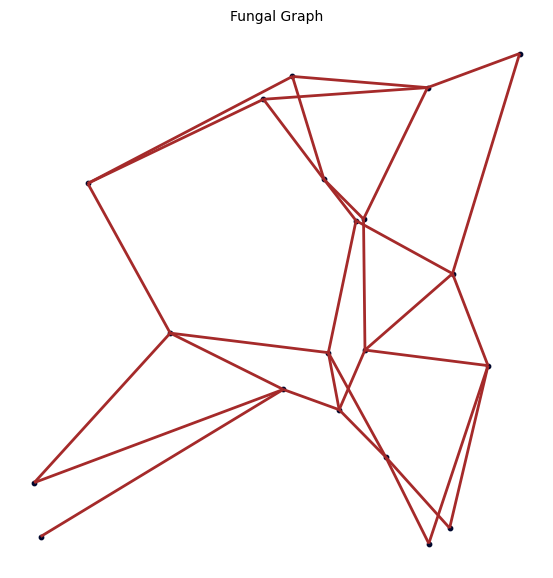

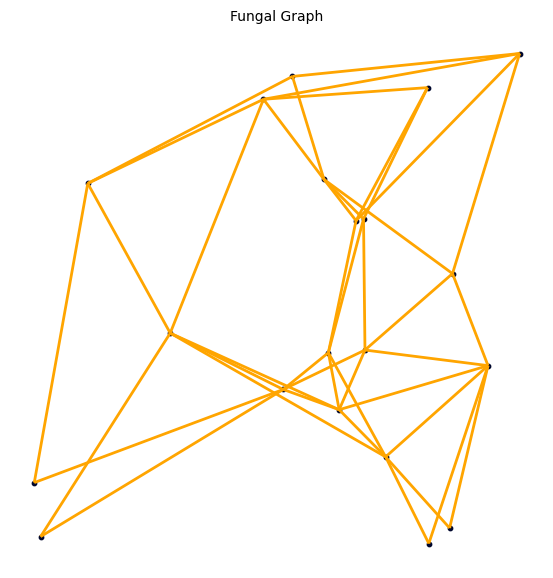

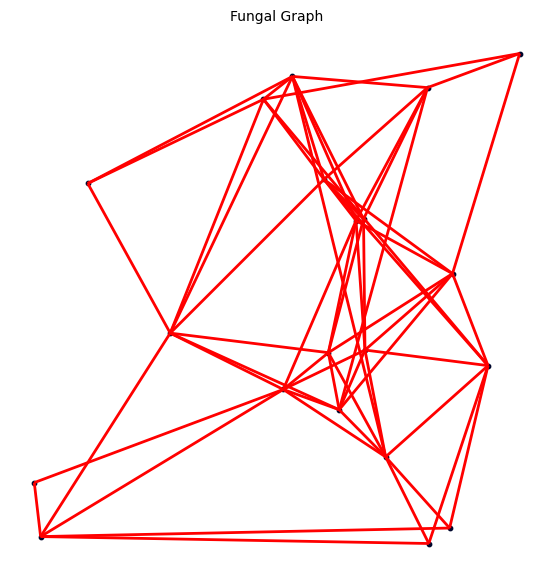

In [26]:
conservative.draw(
    figsize=(7, 7),
    e_size=[2],
    e_color="brown",
    v_size=10
)
balanced.draw(
    figsize=(7, 7),
    e_size=[2],
    e_color="orange",
    v_size=10
)
robust.draw(
    figsize=(7, 7),
    e_size=[2],
    e_color="red",
    v_size=10
)

In [27]:
from proximitygraphs import MST, DelaunayG

mst = MST(points)
delaunay = DelaunayG(points)
fungal = FungalGraph(points, seed=42)

import numpy as np

print(f"\n{'Grafo':<20} {'Aristas':<10} {'Comp.':<8} {'Long. Total':<15} {'Grado Medio':<12}")
print("-"*70)
print(f"{'MST':<20} {mst.m:<10} {mst.cc:<8} {sum(mst.lengths):<15.2f} {np.mean(mst.graph.degree()):<12.2f}")
print(f"{'Delaunay':<20} {delaunay.m:<10} {delaunay.cc:<8} {sum(delaunay.lengths):<15.2f} {np.mean(delaunay.graph.degree()):<12.2f}")
print(f"{'FungalGraph':<20} {fungal.m:<10} {fungal.cc:<8} {sum(fungal.lengths):<15.2f} {np.mean(fungal.graph.degree()):<12.2f}")




Grafo                Aristas    Comp.    Long. Total     Grado Medio 
----------------------------------------------------------------------
MST                  19         1        3.28            1.90        
Delaunay             49         1        14.33           4.90        
FungalGraph          42         1        12.96           4.20        


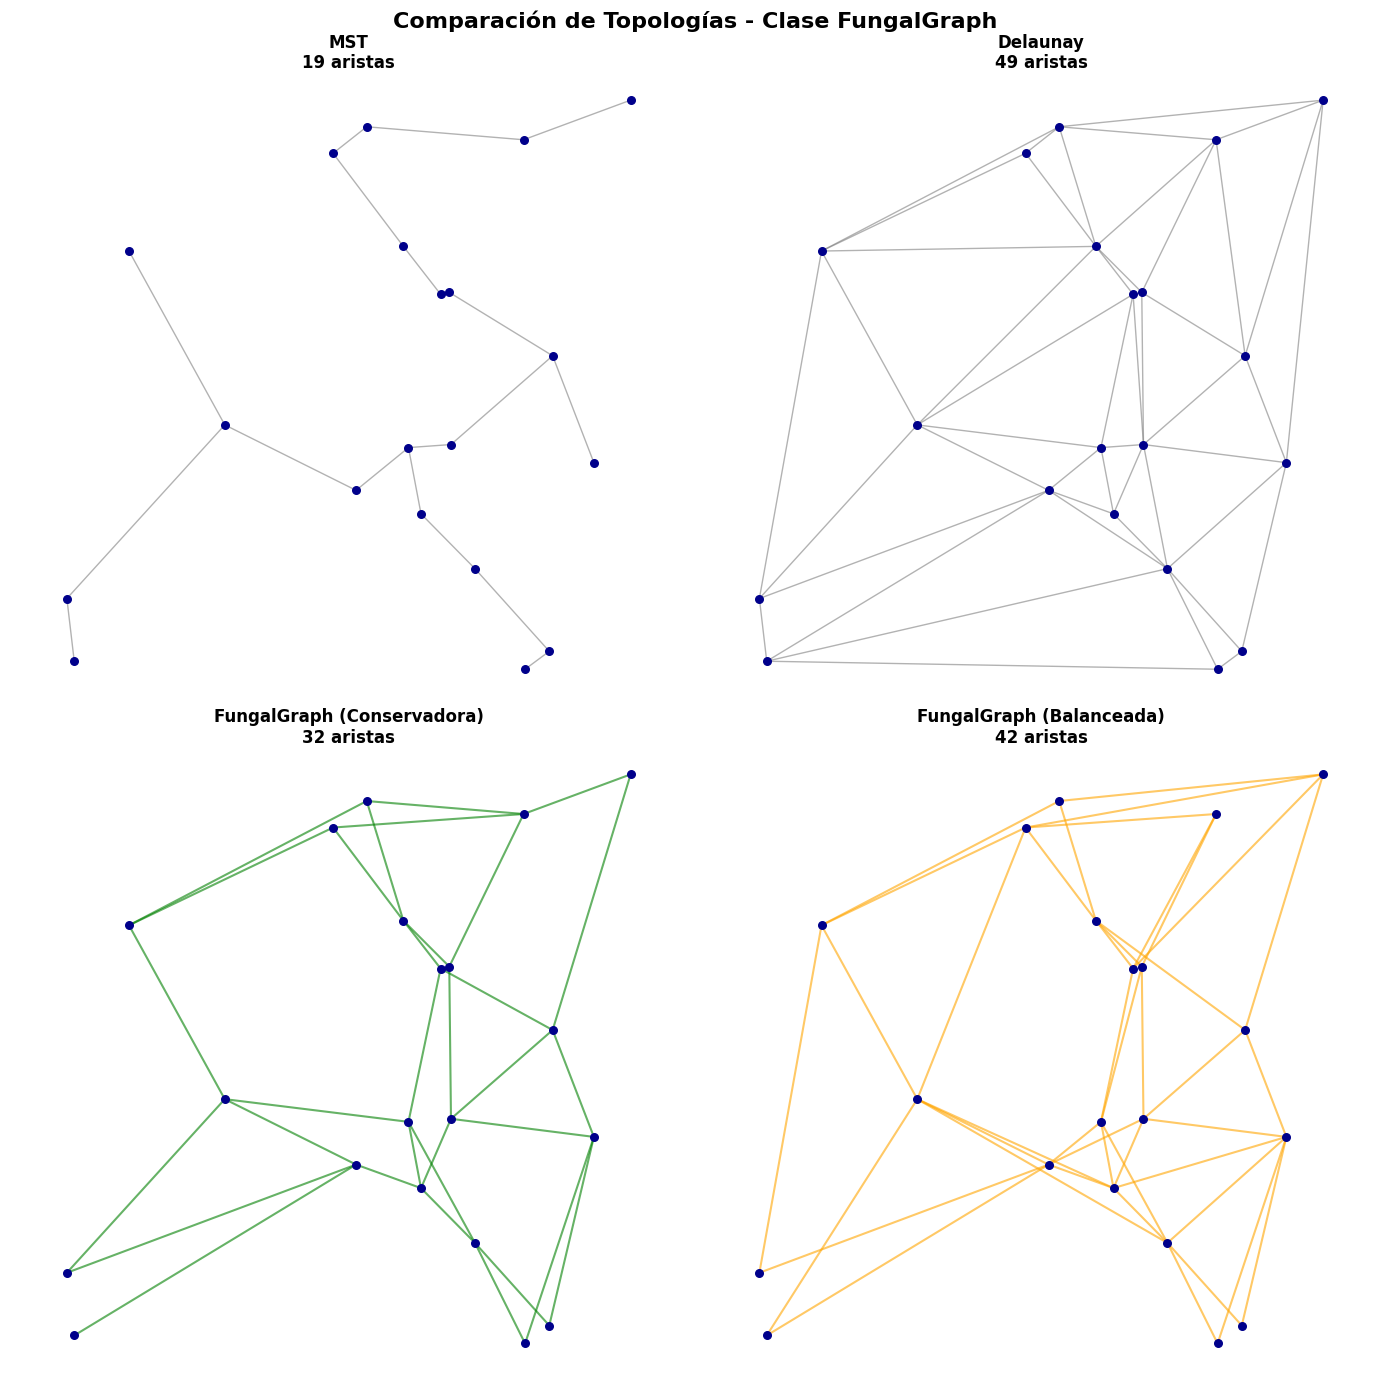

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# MST
axes[0, 0].scatter(points.points[:, 0], points.points[:, 1], c='darkblue', s=30, zorder=3)
for i, j in mst.graph.get_edgelist():
    p1, p2 = points.points[i], points.points[j]
    axes[0, 0].plot([p1[0], p2[0]], [p1[1], p2[1]], 'gray', linewidth=1, alpha=0.6)
axes[0, 0].set_title(f'MST\n{mst.m} aristas', fontsize=12, fontweight='bold')
axes[0, 0].axis('equal')
axes[0, 0].axis('off')

# Delaunay
axes[0, 1].scatter(points.points[:, 0], points.points[:, 1], c='darkblue', s=30, zorder=3)
for i, j in delaunay.graph.get_edgelist():
    p1, p2 = points.points[i], points.points[j]
    axes[0, 1].plot([p1[0], p2[0]], [p1[1], p2[1]], 'gray', linewidth=1, alpha=0.6)
axes[0, 1].set_title(f'Delaunay\n{delaunay.m} aristas', fontsize=12, fontweight='bold')
axes[0, 1].axis('equal')
axes[0, 1].axis('off')

# FungalGraph Conservadora
axes[1, 0].scatter(points.points[:, 0], points.points[:, 1], c='darkblue', s=30, zorder=3)
for i, j in conservative.graph.get_edgelist():
    p1, p2 = points.points[i], points.points[j]
    axes[1, 0].plot([p1[0], p2[0]], [p1[1], p2[1]], 'green', linewidth=1.5, alpha=0.6)
axes[1, 0].set_title(f'FungalGraph (Conservadora)\n{conservative.m} aristas', 
                     fontsize=12, fontweight='bold')
axes[1, 0].axis('equal')
axes[1, 0].axis('off')

# FungalGraph Balanceada
axes[1, 1].scatter(points.points[:, 0], points.points[:, 1], c='darkblue', s=30, zorder=3)
for i, j in balanced.graph.get_edgelist():
    p1, p2 = points.points[i], points.points[j]
    axes[1, 1].plot([p1[0], p2[0]], [p1[1], p2[1]], 'orange', linewidth=1.5, alpha=0.6)
axes[1, 1].set_title(f'FungalGraph (Balanceada)\n{balanced.m} aristas', 
                     fontsize=12, fontweight='bold')
axes[1, 1].axis('equal')
axes[1, 1].axis('off')

plt.suptitle('Comparación de Topologías - Clase FungalGraph', 
            fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()

